In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt

from src.env.pricing_env import DynamicPricingEnv
from src.agents.baseline import (
    FixedPriceAgent,
    TimeBasedDiscountAgent,
)

from src.utils.evaluate import evaluate_agent

In [2]:
env = DynamicPricingEnv()

fixed_agent = FixedPriceAgent(price_index=2)

fixed_results = evaluate_agent(
    env,
    fixed_agent,
    episodes=200
)

In [3]:
discount_agent = TimeBasedDiscountAgent()

discount_results = evaluate_agent(
    env,
    discount_agent,
    episodes=200
)

In [4]:
print("Fixed Price")

print(fixed_results)

print()

print("Time-Based Discount")

print(discount_results)

Fixed Price
{'average_revenue': np.float64(1443.0), 'max_revenue': np.int64(2280), 'min_revenue': np.int64(480), 'std_revenue': np.float64(332.64846309580327), 'revenues': [1320, 1800, 1920, 1200, 1320, 1200, 1800, 1440, 960, 1200, 1080, 1680, 1440, 1440, 1200, 1320, 1200, 1440, 1800, 1200, 1440, 1440, 1440, 1200, 1200, 1200, 840, 2160, 1680, 840, 1920, 1320, 960, 2160, 1320, 1800, 1920, 1080, 1560, 1200, 1320, 1560, 1200, 1080, 1560, 1800, 1920, 1200, 1080, 1440, 1920, 1920, 1320, 720, 1680, 1440, 1320, 1440, 1800, 2280, 1320, 1080, 960, 1680, 1560, 1320, 1320, 1560, 1200, 1800, 1440, 1680, 1560, 1680, 720, 1080, 1440, 1440, 2040, 1320, 1440, 1680, 960, 1800, 1320, 1680, 1080, 1680, 1320, 1320, 960, 1920, 1800, 1680, 1440, 1920, 1200, 1440, 1800, 1440, 1200, 1440, 840, 1560, 1200, 1080, 1080, 1080, 2280, 1560, 1320, 1680, 1440, 840, 1440, 1200, 1320, 1200, 1800, 1320, 1560, 1440, 1080, 840, 1440, 1440, 1680, 1080, 1440, 1440, 1320, 1920, 1680, 840, 1800, 1440, 1560, 1440, 1800, 1800, 

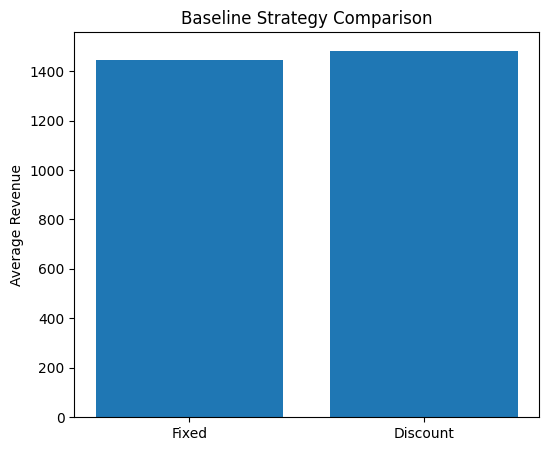

In [5]:
strategies = [
    "Fixed",
    "Discount"
]

average_revenue = [
    fixed_results["average_revenue"],
    discount_results["average_revenue"]
]

plt.figure(figsize=(6,5))

plt.bar(
    strategies,
    average_revenue
)

plt.title("Baseline Strategy Comparison")

plt.ylabel("Average Revenue")

plt.show()

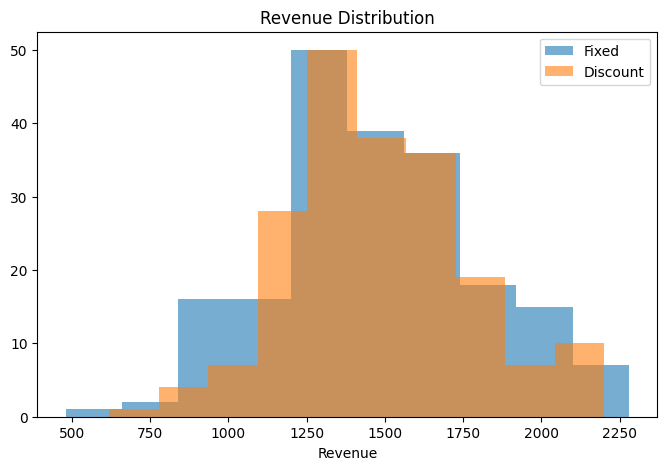

In [6]:
plt.figure(figsize=(8,5))

plt.hist(
    fixed_results["revenues"],
    alpha=0.6,
    label="Fixed"
)

plt.hist(
    discount_results["revenues"],
    alpha=0.6,
    label="Discount"
)

plt.legend()

plt.title("Revenue Distribution")

plt.xlabel("Revenue")

plt.show()